# Discrete-time Invariant Set


In this example we compute the maximal (resp. minimal) invariant set contained
in (resp. containing) the square with vertices $(\pm 1, \pm 1)$ for the system
$$
\begin{aligned}
x_{k+1} & = -y_k\\
y_{k+1} & =  x_k.
\end{aligned}
$$

The system is $x_{k+1} = A x_k$ where
$$
A = \begin{bmatrix}
0 & -1\\
1 & 0
\end{bmatrix}.
$$
A set $S$ is invariant if $A S \subseteq S$.

In [1]:
using Polyhedra
h = HalfSpace([1, 0], 1.0) ∩ HalfSpace([-1, 0], 1) ∩ HalfSpace([0, 1], 1) ∩ HalfSpace([0, -1], 1)
□ = polyhedron(h)

Polyhedron DefaultPolyhedron{Float64, Polyhedra.Intersection{Float64, Vector{Float64}, Int64}, Polyhedra.Hull{Float64, Vector{Float64}, Int64}}:
4-element iterator of HalfSpace{Float64, Vector{Float64}}:
 HalfSpace([1.0, 0.0], 1.0)
 HalfSpace([-1.0, 0.0], 1.0)
 HalfSpace([0.0, 1.0], 1.0)
 HalfSpace([0.0, -1.0], 1.0)

We need to pick an SDP solver, see
[here](https://jump.dev/JuMP.jl/stable/installation/#Supported-solvers)
for a list of available ones.

In [2]:
using SetProg
import CSDP
sdp_solver = optimizer_with_attributes(CSDP.Optimizer, MOI.Silent() => true)

A = [0.0 -1.0
     1.0  0.0]

2×2 Matrix{Float64}:
 0.0  -1.0
 1.0   0.0

## Ellipsoidal template

We first look for the largest ellipsoid contained in the square that is
invariant under `A`.

In [3]:
model = Model(sdp_solver)
@variable(model, S, Ellipsoid(symmetric=true))
@constraint(model, S ⊆ □)
@constraint(model, A * S ⊆ S)
@objective(model, Max, nth_root(volume(S)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
maximal = value(S)

solve_time(model) = 0.0060389041900634766
termination_status(model) = OPTIMAL
objective_value(model) = 0.999999998499933


SetProg.Sets.Polar{Float64, SetProg.Sets.Ellipsoid{Float64}}(SetProg.Sets.Ellipsoid{Float64}([0.9999999992495548 0.0; 0.0 0.999999999251015]))

We then look for the smallest invariant ellipsoid containing the square.

In [4]:
model = Model(sdp_solver)
@variable(model, S, Ellipsoid(symmetric=true))
@constraint(model, □ ⊆ S)
@constraint(model, A * S ⊆ S)
@objective(model, Min, nth_root(volume(S)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
minimal = value(S)

solve_time(model) = 0.006072044372558594
termination_status(model) = OPTIMAL
objective_value(model) = 0.4999999994334351


SetProg.Sets.Ellipsoid{Float64}([0.4999999997158233 -7.327471962526033e-15; -7.327471962526033e-15 0.49999999971591985])

We plot the two ellipsoids together with the square.

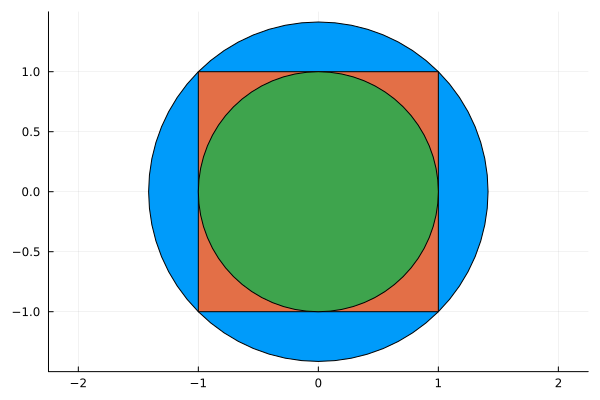

In [5]:
using Plots
plot(ratio=:equal)
plot!(minimal)
plot!(□)
plot!(maximal)

## Quartic template

We can also look for convex sublevel sets of a quartic polynomial.

In [6]:
model = Model(sdp_solver)
@variable(model, S, PolySet(degree=4, convex=true, symmetric=true))
@constraint(model, S ⊆ □)
@constraint(model, A * S ⊆ S)
@objective(model, Max, nth_root(volume(S)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
maximal_convex = value(S)

solve_time(model) = 0.010554075241088867
termination_status(model) = OPTIMAL
objective_value(model) = 6.447419586602629


SetProg.Sets.Polar{Float64, SetProg.Sets.ConvexPolySet{Float64, StarAlgebras.SubBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Int64, Vector{Int64}, StarAlgebras.MappedBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Vector{Int64}, MultivariatePolynomials.ExponentsIterator{MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}, Nothing, Vector{Int64}}, MultivariateBases.Variables{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}}, typeof(MultivariatePolynomials.exponents)}, Vector{Vector{Int64

And the minimal containing the square:

In [7]:
model = Model(sdp_solver)
@variable(model, S, PolySet(degree=4, convex=true, symmetric=true))
@constraint(model, □ ⊆ S)
@constraint(model, A * S ⊆ S)
@objective(model, Min, nth_root(volume(S)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
minimal_convex = value(S)

solve_time(model) = 0.010127067565917969
termination_status(model) = OPTIMAL
objective_value(model) = 1.6118548936057875


SetProg.Sets.ConvexPolySet{Float64, StarAlgebras.SubBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Int64, Vector{Int64}, StarAlgebras.MappedBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Vector{Int64}, MultivariatePolynomials.ExponentsIterator{MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}, Nothing, Vector{Int64}}, MultivariateBases.Variables{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}}, typeof(MultivariatePolynomials.exponents)}, Vector{Vector{Int64}}}, Float64}(4, GramMatrix 

We plot the two quartic sublevel sets together with the square.

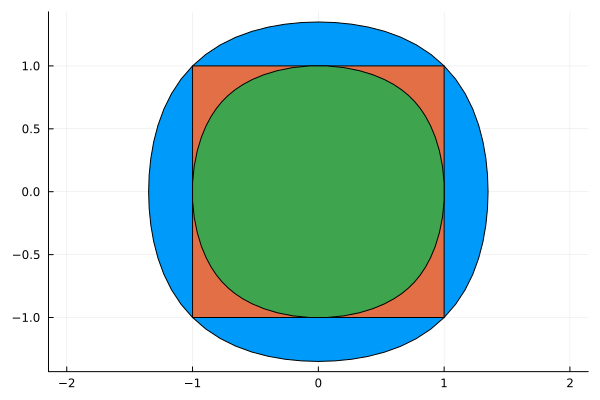

In [8]:
plot(ratio=:equal)
plot!(minimal_convex)
plot!(□)
plot!(maximal_convex)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*